# Programación Genética para Diseño de Circuito Lógico
## Codificador de 7 Segmentos

Este notebook implementa un algoritmo de Programación Genética para encontrar automáticamente la lógica digital de un codificador de 7 segmentos usando la librería **DEAP** (Distributed Evolutionary Algorithms in Python).

## 1. Conceptos Teóricos

### 1.1 Conjunto de Terminales (Inputs)
Para un codificador de 7 segmentos que maneja dígitos 0-9:
- **4 terminales binarias**: a, b, c, d (entrada de 4 bits)
- **1 terminal constante**: 1.0 (constante booleana verdadera)

### 1.2 Conjunto de Funciones
Operaciones lógicas binarias:
- **AND**: Conjunción lógica
- **OR**: Disyunción lógica
- **NOT**: Negación lógica
- **XOR**: OR exclusivo

### 1.3 Función de Aptitud
Evalúa qué tan bien el árbol sintáctico generado produce las salidas correctas:
- **Aptitud = número de casos de prueba correctos (de 10 dígitos)**
- Rango: 0 a 10 (donde 10 es perfecto)

### 1.4 Estructura de un Codificador 7 Segmentos
```
  aaa
 f   b
  ggg
 e   c
  ddd
```
- Entrada: 4 bits (representa dígitos 0-9)
- Salida: 7 bits (a, b, c, d, e, f, g)
- Total: 7 ecuaciones booleanas independientes a evolucionar

## 2. Instalación de Dependencias

In [103]:
!pip install deap numpy matplotlib -q

## 3. Importaciones y Configuración

In [104]:
import numpy as np
import random
from deap import base, creator, gp, tools, algorithms
import matplotlib.pyplot as plt
from functools import wraps
import operator

# Configurar semilla para reproducibilidad
random.seed(42)
np.random.seed(42)

print("✓ Importaciones exitosas")

✓ Importaciones exitosas


## 4. Definición de Datos de Entrenamiento

Tabla de verdad del codificador 7-segmentos para dígitos 0-9

In [105]:
# Tabla de verdad: 7-segment display decoder
# Dígito -> (a, b, c, d, e, f, g)
#         Segmentos del display
truth_table = {
    0: (1, 1, 1, 1, 1, 1, 0),  # 0
    1: (0, 1, 1, 0, 0, 0, 0),  # 1
    2: (1, 1, 0, 1, 1, 0, 1),  # 2
    3: (1, 1, 1, 1, 0, 0, 1),  # 3
    4: (0, 1, 1, 0, 0, 1, 1),  # 4
    5: (1, 0, 1, 1, 0, 1, 1),  # 5
    6: (1, 0, 1, 1, 1, 1, 1),  # 6
    7: (1, 1, 1, 0, 0, 0, 0),  # 7
    8: (1, 1, 1, 1, 1, 1, 1),  # 8
    9: (1, 1, 1, 1, 0, 1, 1),  # 9
}

# Convertir a formato binario de 4 bits
test_cases = []
segment_labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g']

for digit in range(10):
    # Convertir a 4 bits
    bits = [(digit >> i) & 1 for i in range(4)]  # [LSB, ..., MSB]
    output = truth_table[digit]
    test_cases.append((bits, output))

print("Tabla de verdad - Codificador 7-Segmentos:")
print("Dígito | Entrada (d c b a) | Salida (a b c d e f g)")
print("-" * 50)
for digit in range(10):
    bits, output = test_cases[digit]
    bits_str = ''.join(str(b) for b in reversed(bits))
    output_str = ''.join(str(o) for o in output)
    print(f"{digit:6} | {bits_str:17} | {output_str}")

Tabla de verdad - Codificador 7-Segmentos:
Dígito | Entrada (d c b a) | Salida (a b c d e f g)
--------------------------------------------------
     0 | 0000              | 1111110
     1 | 0001              | 0110000
     2 | 0010              | 1101101
     3 | 0011              | 1111001
     4 | 0100              | 0110011
     5 | 0101              | 1011011
     6 | 0110              | 1011111
     7 | 0111              | 1110000
     8 | 1000              | 1111111
     9 | 1001              | 1111011


## 5. Definición de Funciones Lógicas

In [106]:
# Definir operaciones lógicas que trabajen con valores binarios
def safe_and(a, b):
    """AND lógico"""
    return int(bool(a) and bool(b))

def safe_or(a, b):
    """OR lógico"""
    return int(bool(a) or bool(b))

def safe_xor(a, b):
    """XOR lógico"""
    return int(bool(a) != bool(b))

def safe_not(a):
    """NOT lógico"""
    return int(not bool(a))

print("✓ Funciones lógicas definidas")

✓ Funciones lógicas definidas


## 6. Configuración de DEAP

In [107]:
import numpy as np
import random
from deap import base, creator, gp, tools, algorithms
import matplotlib.pyplot as plt
from functools import wraps
import operator

# Configurar semilla para reproducibilidad
random.seed(42)
np.random.seed(42)

print("✓ Importaciones exitosas")

# Crear el environment de DEAP (usando PrimitiveSetTyped para tipos explícitos)
# Las entradas 'a', 'b', 'c', 'd' son de tipo int y la expresión principal retorna int.
pset = gp.PrimitiveSetTyped("MAIN", in_types=[int, int, int, int], ret_type=int)

# Asignar nombres a los argumentos de entrada de MAIN
pset.renameArguments(ARG0='a', ARG1='b', ARG2='c', ARG3='d')

# Agregar terminales (inputs) con su tipo explícito
pset.addTerminal(1, int, 'ONE')  # Constante 1 de tipo int
pset.addTerminal(0, int, 'ZERO') # Constante 0 de tipo int

# Agregar funciones primitivas con tipos de entrada y retorno explícitos
# Formato: addPrimitive(function, in_types, ret_type, name)
pset.addPrimitive(safe_and, [int, int], int, 'AND')
pset.addPrimitive(safe_or, [int, int], int, 'OR')
pset.addPrimitive(safe_xor, [int, int], int, 'XOR')
pset.addPrimitive(safe_not, [int], int, 'NOT')

# Crear tipos de fitness y individuo
creator.create("FitnessMax", base.Fitness, weights=(1.0,))  # Maximizar aptitud
creator.create("Individual", gp.PrimitiveTree, fitness=creator.FitnessMax)

# Crear toolbox
toolbox = base.Toolbox()
# Aumentar min_ y max_ para generar árboles iniciales más complejos
toolbox.register("expr", gp.genHalfAndHalf, pset=pset, min_=2, max_=6)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.expr)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

print("✓ Configuración de DEAP completada")
print(f"\nConjunto de Primitivos (Pset):")
print(f"  Inputs (arity): {len(pset.arguments)}")

# Collect names of all explicit terminals and arguments
all_terminals_names = [arg for arg in pset.arguments] # Inputs 'a', 'b', 'c', 'd' (already strings)
if int in pset.terminals: # Check if int type terminals exist
    all_terminals_names.extend([t.name for t in pset.terminals[int]]) # Constants 'ONE', 'ZERO'

all_primitives_names = []
if int in pset.primitives: # Check if int type primitives exist
    all_primitives_names.extend([p.name for p in pset.primitives[int]]) # Functions 'AND', 'OR', 'XOR', 'NOT'

print(f"  Terminales (Inputs + Constantes): {sorted(all_terminals_names)}")
print(f"  Primitivas (Funciones): {sorted(all_primitives_names)}")

✓ Importaciones exitosas
✓ Configuración de DEAP completada

Conjunto de Primitivos (Pset):
  Inputs (arity): 4
  Terminales (Inputs + Constantes): ['ARG0', 'ARG1', 'ARG2', 'ARG3', 'ONE', 'ZERO', 'a', 'b', 'c', 'd']
  Primitivas (Funciones): ['AND', 'NOT', 'OR', 'XOR']


/usr/local/lib/python3.12/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/usr/local/lib/python3.12/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


## 7. Función de Aptitud (Fitness)

In [108]:
def evaluate_individual(individual, segment_index):
    """
    Evalúa un árbol sintáctico para un segmento específico.

    Args:
        individual: Árbol sintáctico (expresión)
        segment_index: Índice del segmento (0-6 para a-g)

    Returns:
        tuple: (aptitud,) - número de casos de prueba correctos
    """
    # Compilar la expresión
    try:
        func = gp.compile(individual, pset)
    except:
        return (0,)  # Si falla la compilación, aptitud = 0

    correct_cases = 0

    # Evaluar para cada caso de prueba
    for bits, expected_outputs in test_cases:
        try:
            # Evaluar la función con los bits como entrada
            # Usamos dict para pasar los valores de entrada
            result = func(
                a=bits[0],
                b=bits[1],
                c=bits[2],
                d=bits[3],
                ONE=1,
                ZERO=0
            )

            # Convertir resultado a binario (0 o 1)
            predicted = int(bool(result))

            # Comparar con valor esperado
            if predicted == expected_outputs[segment_index]:
                correct_cases += 1
        except:
            # Error durante evaluación
            pass

    return (correct_cases,)

# Crear funciones de evaluación para cada segmento
def create_evaluate_func(segment_index):
    """Factory para crear funciones de evaluación para cada segmento"""
    def evaluate_segment(individual):
        return evaluate_individual(individual, segment_index)
    return evaluate_segment

print("✓ Función de aptitud definida")
print("\nDefinición de Aptitud:")
print("  - Evalúa un árbol sintáctico contra 10 casos de prueba")
print("  - Retorna el número de predicciones correctas (0-10)")
print("  - Máxima aptitud: 10 (todas las predicciones correctas)")

✓ Función de aptitud definida

Definición de Aptitud:
  - Evalúa un árbol sintáctico contra 10 casos de prueba
  - Retorna el número de predicciones correctas (0-10)
  - Máxima aptitud: 10 (todas las predicciones correctas)


## 8. Configuración de Operadores Genéticos

In [109]:
# Registrar operadores genéticos en el toolbox
toolbox.register("mate", gp.cxOnePoint)  # Cruce de un punto
toolbox.register("expr_mut", gp.genFull, min_=0, max_=4)  # Para mutación, también se aumenta un poco
toolbox.register("mutate", gp.mutUniform, expr=toolbox.expr_mut, pset=pset)  # Mutación uniforme
toolbox.register("select", tools.selTournament, tournsize=3) # Selección por torneo

# Validar que los árboles no sean demasiado grandes
# Se aumenta el límite de altura para permitir soluciones más complejas
toolbox.decorate("mate", gp.staticLimit(key=operator.attrgetter("height"), max_value=15))
toolbox.decorate("mutate", gp.staticLimit(key=operator.attrgetter("height"), max_value=15))

print("✓ Operadores genéticos configurados:")
print("  - Cruce (mate): One-point crossover")
print("  - Mutación: Uniform mutation")
print("  - Selección: Tournament selection (tournsize=3)")
print("  - Límite de altura del árbol: 15")

✓ Operadores genéticos configurados:
  - Cruce (mate): One-point crossover
  - Mutación: Uniform mutation
  - Selección: Tournament selection (tournsize=3)
  - Límite de altura del árbol: 15


## 9. Función para Evolucionar un Segmento

In [110]:
def evolve_segment(segment_index, segment_name, generations=50, population_size=100):
    """
    Evoluciona una solución para un segmento específico.

    Args:
        segment_index: Índice del segmento (0-6)
        segment_name: Nombre del segmento ('a', 'b', etc.)
        generations: Número de generaciones
        population_size: Tamaño de la población

    Returns:
        tuple: (mejor_individual, historial_estadísticas)
    """
    # Registrar función de evaluación para este segmento
    toolbox.register("evaluate", create_evaluate_func(segment_index))

    # Crear población inicial
    population = toolbox.population(n=population_size)

    # Estadísticas
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)

    # Ejecutar algoritmo genético simple
    population, logbook = algorithms.eaSimple(
        population, toolbox,
        cxpb=0.7,  # Probabilidad de cruce
        mutpb=0.3,  # Probabilidad de mutación
        ngen=generations,
        stats=stats,
        verbose=False
    )

    # Obtener mejor individuo
    best_individual = tools.selBest(population, 1)[0]
    best_fitness = best_individual.fitness.values[0]

    return best_individual, best_fitness, logbook

print("✓ Función de evolución definida")

✓ Función de evolución definida


## 10. Ejecutar Evolución para Todos los Segmentos

In [111]:
# Parámetros de evolución
GENERATIONS = 100
POPULATION_SIZE = 1000

# Almacenar resultados
segment_labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g']
best_solutions = {}
fitness_histories = {}

print("="*60)
print("EVOLUCIÓN DE CIRCUITO LÓGICO - CODIFICADOR 7 SEGMENTOS")
print("="*60)
print(f"\nParámetros:")
print(f"  - Generaciones: {GENERATIONS}")
print(f"  - Tamaño de población: {POPULATION_SIZE}")
print(f"  - Segmentos a evolucionar: 7 (a, b, c, d, e, f, g)")
print(f"\nEvolución en progreso...\n")

# Evolucionar cada segmento
for i, seg_name in enumerate(segment_labels, 1):
    print(f"[{i}/7] Evolucionando segmento '{seg_name}'...", end=' ', flush=True)

    best_ind, best_fit, logbook = evolve_segment(
        segment_index=i-1,
        segment_name=seg_name,
        generations=GENERATIONS,
        population_size=POPULATION_SIZE
    )

    best_solutions[seg_name] = best_ind
    fitness_histories[seg_name] = logbook

    print(f"✓ Aptitud: {best_fit}/10")

print("\n" + "="*60)
print("EVOLUCIÓN COMPLETADA")
print("="*60)

EVOLUCIÓN DE CIRCUITO LÓGICO - CODIFICADOR 7 SEGMENTOS

Parámetros:
  - Generaciones: 100
  - Tamaño de población: 1000
  - Segmentos a evolucionar: 7 (a, b, c, d, e, f, g)

Evolución en progreso...

[1/7] Evolucionando segmento 'a'... ✓ Aptitud: 0.0/10
[2/7] Evolucionando segmento 'b'... ✓ Aptitud: 0.0/10
[3/7] Evolucionando segmento 'c'... ✓ Aptitud: 0.0/10
[4/7] Evolucionando segmento 'd'... ✓ Aptitud: 0.0/10
[5/7] Evolucionando segmento 'e'... ✓ Aptitud: 0.0/10
[6/7] Evolucionando segmento 'f'... ✓ Aptitud: 0.0/10
[7/7] Evolucionando segmento 'g'... ✓ Aptitud: 0.0/10

EVOLUCIÓN COMPLETADA


## 11. Visualización de Resultados

In [112]:
# Resumen de soluciones
print("\n" + "="*60)
print("SOLUCIONES EVOLUCIONADAS")
print("="*60)

total_fitness = 0
for seg_name in segment_labels:
    best_ind = best_solutions[seg_name]
    fitness = evaluate_individual(best_ind, segment_labels.index(seg_name))[0]
    total_fitness += fitness
    accuracy = (fitness / 10) * 100

    print(f"\nSegmento '{seg_name}':")
    print(f"  Expresión: {best_ind}")
    print(f"  Aptitud: {fitness}/10 ({accuracy:.1f}%)")

print(f"\n{'='*60}")
print(f"Aptitud Total: {total_fitness}/70 ({(total_fitness/70)*100:.1f}%)")
print(f"{'='*60}")


SOLUCIONES EVOLUCIONADAS

Segmento 'a':
  Expresión: OR(NOT(XOR(ONE, a)), NOT(OR(ZERO, OR(AND(c, b), NOT(ZERO)))))
  Aptitud: 0/10 (0.0%)

Segmento 'b':
  Expresión: OR(c, XOR(AND(OR(NOT(b), NOT(d)), XOR(a, ZERO)), NOT(XOR(ONE, ONE))))
  Aptitud: 0/10 (0.0%)

Segmento 'c':
  Expresión: XOR(OR(XOR(XOR(AND(OR(XOR(OR(b, b), b), XOR(XOR(ONE, a), OR(OR(ZERO, AND(NOT(NOT(OR(d, c))), OR(XOR(ONE, AND(NOT(ONE), OR(ZERO, a))), a))), XOR(c, ZERO)))), OR(AND(XOR(c, c), OR(d, ZERO)), AND(AND(ONE, ONE), AND(c, ONE)))), d), NOT(XOR(NOT(NOT(XOR(AND(b, b), NOT(b)))), NOT(AND(c, ZERO))))), ZERO), AND(NOT(OR(c, a)), XOR(NOT(XOR(b, AND(OR(ONE, XOR(XOR(d, d), NOT(a))), ONE))), ONE)))
  Aptitud: 0/10 (0.0%)

Segmento 'd':
  Expresión: AND(NOT(ZERO), AND(XOR(AND(ZERO, AND(OR(NOT(ZERO), AND(b, ZERO)), OR(NOT(NOT(NOT(NOT(XOR(a, c))))), XOR(a, b)))), AND(NOT(b), OR(XOR(NOT(XOR(b, d)), NOT(AND(c, c))), OR(NOT(XOR(d, b)), XOR(AND(ONE, a), OR(OR(AND(b, ZERO), OR(c, b)), XOR(d, b))))))), b))
  Aptitud: 0/10 (0.0%)

## 12. Gráficas de Convergencia

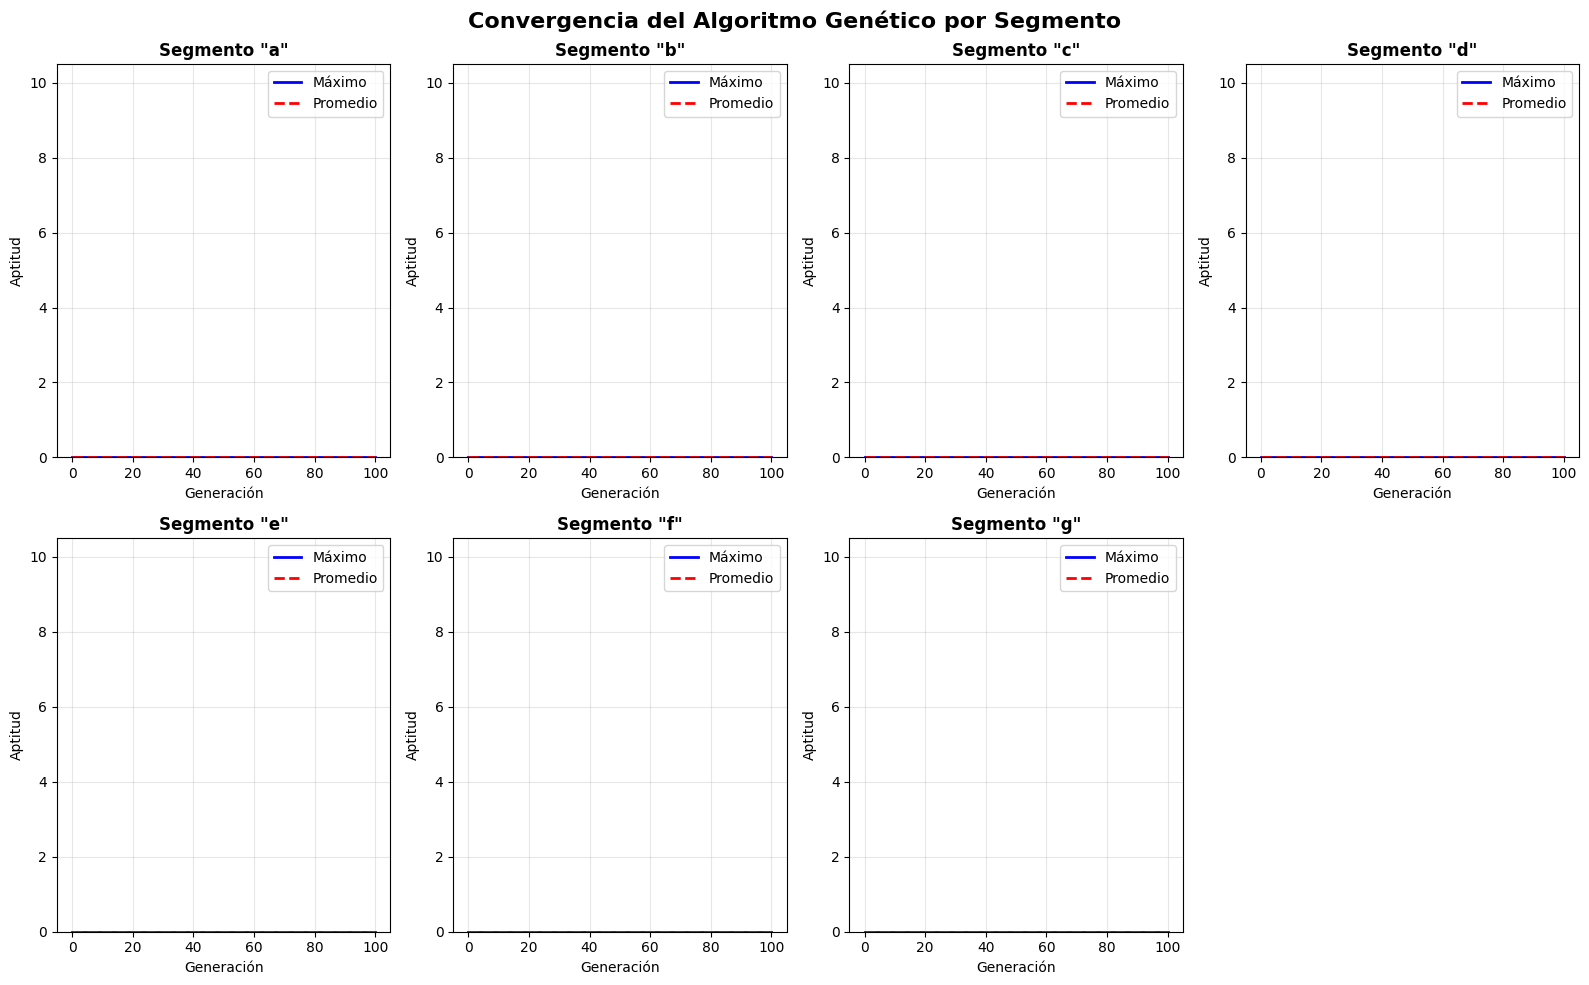

✓ Gráfica de convergencia guardada


In [113]:
# Graficar convergencia para todos los segmentos
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
fig.suptitle('Convergencia del Algoritmo Genético por Segmento', fontsize=16, fontweight='bold')

axes_flat = axes.flatten()

for idx, seg_name in enumerate(segment_labels):
    ax = axes_flat[idx]
    logbook = fitness_histories[seg_name]

    # Extraer datos
    generations = [record['gen'] for record in logbook]
    max_fitness = [record['max'] for record in logbook]
    avg_fitness = [record['avg'] for record in logbook]

    # Graficar
    ax.plot(generations, max_fitness, 'b-', linewidth=2, label='Máximo')
    ax.plot(generations, avg_fitness, 'r--', linewidth=2, label='Promedio')
    ax.set_xlabel('Generación', fontsize=10)
    ax.set_ylabel('Aptitud', fontsize=10)
    ax.set_title(f'Segmento "{seg_name}"', fontsize=12, fontweight='bold')
    ax.set_ylim([0, 10.5])
    ax.grid(True, alpha=0.3)
    ax.legend()

# Eliminar subplot vacío
fig.delaxes(axes_flat[-1])

plt.tight_layout()
plt.savefig('/content/convergencia_7segmentos.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Gráfica de convergencia guardada")

## 13. Validación de Soluciones

In [114]:
print("\n" + "="*80)
print("VALIDACIÓN DETALLADA - TABLA DE VERDAD PREDICHA vs ESPERADA")
print("="*80)

# Para cada caso de prueba
validation_results = []

for digit in range(10):
    bits, expected_outputs = test_cases[digit]
    predicted_outputs = []

    # Evaluar cada segmento
    for seg_idx, seg_name in enumerate(segment_labels):
        individual = best_solutions[seg_name]
        try:
            func = gp.compile(individual, pset)
            result = func(
                a=bits[0],
                b=bits[1],
                c=bits[2],
                d=bits[3],
                ONE=1,
                ZERO=0
            )
            predicted = int(bool(result))
        except:
            predicted = 0

        predicted_outputs.append(predicted)

    # Comparar
    expected_str = ''.join(str(e) for e in expected_outputs)
    predicted_str = ''.join(str(p) for p in predicted_outputs)
    match = "✓ CORRECTO" if expected_str == predicted_str else "✗ ERROR"

    validation_results.append({
        'digit': digit,
        'expected': expected_str,
        'predicted': predicted_str,
        'correct': expected_str == predicted_str
    })

    print(f"Dígito {digit} | Esperado: {expected_str} | Predicción: {predicted_str} | {match}")

# Calcular accuracy general
correct_predictions = sum(1 for r in validation_results if r['correct'])
total_accuracy = (correct_predictions / 10) * 100

print("\n" + "="*80)
print(f"EXACTITUD GENERAL: {correct_predictions}/10 ({total_accuracy:.1f}%)")
print("="*80)


VALIDACIÓN DETALLADA - TABLA DE VERDAD PREDICHA vs ESPERADA
Dígito 0 | Esperado: 1111110 | Predicción: 0000000 | ✗ ERROR
Dígito 1 | Esperado: 0110000 | Predicción: 0000000 | ✗ ERROR
Dígito 2 | Esperado: 1101101 | Predicción: 0000000 | ✗ ERROR
Dígito 3 | Esperado: 1111001 | Predicción: 0000000 | ✗ ERROR
Dígito 4 | Esperado: 0110011 | Predicción: 0000000 | ✗ ERROR
Dígito 5 | Esperado: 1011011 | Predicción: 0000000 | ✗ ERROR
Dígito 6 | Esperado: 1011111 | Predicción: 0000000 | ✗ ERROR
Dígito 7 | Esperado: 1110000 | Predicción: 0000000 | ✗ ERROR
Dígito 8 | Esperado: 1111111 | Predicción: 0000000 | ✗ ERROR
Dígito 9 | Esperado: 1111011 | Predicción: 0000000 | ✗ ERROR

EXACTITUD GENERAL: 0/10 (0.0%)


## 14. Visualización de Expresiones Sintácticas

In [115]:
# Mostrar complejidad de soluciones
import pandas as pd

complexity_data = []

for seg_name in segment_labels:
    individual = best_solutions[seg_name]
    height = individual.height
    length = len(individual)

    complexity_data.append({
        'Segmento': seg_name,
        'Expresión': str(individual),
        'Altura del Árbol': height,
        'Nodos': length
    })

df_complexity = pd.DataFrame(complexity_data)

print("\n" + "="*100)
print("COMPLEJIDAD DE SOLUCIONES EVOLUCIONADAS")
print("="*100)
print(df_complexity.to_string(index=False))
print(f"\nPromedio de altura: {df_complexity['Altura del Árbol'].mean():.2f}")
print(f"Promedio de nodos: {df_complexity['Nodos'].mean():.2f}")


COMPLEJIDAD DE SOLUCIONES EVOLUCIONADAS
Segmento                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               Expresión  Altura del Árbol  Nodos
       a                                                                                                                                                                                                                                                                                                                                             

## 15. Análisis Comparativo de Fitness

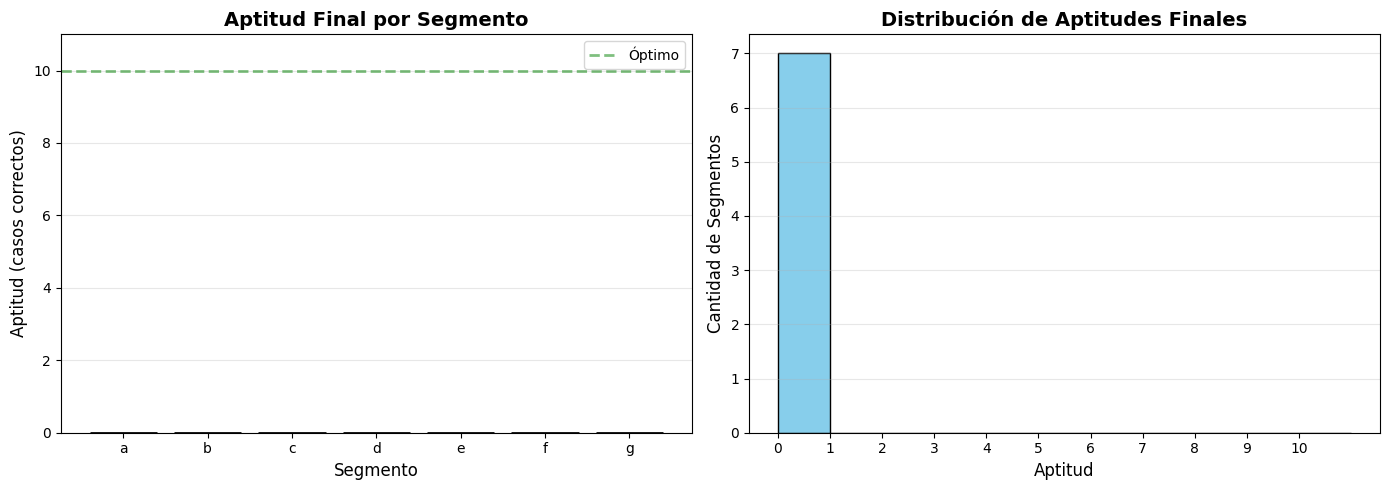

✓ Gráficas de aptitud guardadas


In [116]:
# Gráfica de barras de aptitud final
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Aptitud por segmento
fitness_values = []
for seg_name in segment_labels:
    best_ind = best_solutions[seg_name]
    fitness = evaluate_individual(best_ind, segment_labels.index(seg_name))[0]
    fitness_values.append(fitness)

colors = ['green' if f == 10 else 'orange' if f >= 8 else 'red' for f in fitness_values]
ax1.bar(segment_labels, fitness_values, color=colors, edgecolor='black', linewidth=2)
ax1.set_ylabel('Aptitud (casos correctos)', fontsize=12)
ax1.set_xlabel('Segmento', fontsize=12)
ax1.set_title('Aptitud Final por Segmento', fontsize=14, fontweight='bold')
ax1.set_ylim([0, 11])
ax1.axhline(y=10, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Óptimo')
ax1.grid(True, alpha=0.3, axis='y')
ax1.legend()

# Gráfica 2: Distribución de aptitudes finales
ax2.hist(fitness_values, bins=range(0, 12), edgecolor='black', color='skyblue')
ax2.set_xlabel('Aptitud', fontsize=12)
ax2.set_ylabel('Cantidad de Segmentos', fontsize=12)
ax2.set_title('Distribución de Aptitudes Finales', fontsize=14, fontweight='bold')
ax2.set_xticks(range(0, 11))
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/home/aptitud_segmentos.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Gráficas de aptitud guardadas")

## 16. Resumen y Conclusiones

In [117]:
print("\n" + "#"*80)
print("#" + " "*78 + "#")
print("#" + "RESUMEN DE PROGRAMACIÓN GENÉTICA - CODIFICADOR 7-SEGMENTOS".center(78) + "#")
print("#" + " "*78 + "#")
print("#"*80)

print("\n📊 CONFIGURACIÓN UTILIZADA:")
print(f"   • Librería: DEAP (Distributed Evolutionary Algorithms in Python)")
print(f"   • Generaciones: {GENERATIONS}")
print(f"   • Tamaño de población: {POPULATION_SIZE}")
print(f"   • Probabilidad de cruce: 0.7")
print(f"   • Probabilidad de mutación: 0.3")

print("\n🔧 CONJUNTO DE TERMINALES (INPUTS):")
print("   • a, b, c, d: Bits de entrada (4 bits = dígitos 0-9)")
print("   • ONE: Constante booleana verdadera")
print("   • ZERO: Constante booleana falsa")

print("\n⚙️ CONJUNTO DE FUNCIONES (PRIMITIVOS):")
print("   • AND(x,y): Conjunción lógica")
print("   • OR(x,y): Disyunción lógica")
print("   • XOR(x,y): OR exclusivo")
print("   • NOT(x): Negación")

print("\n📈 FUNCIÓN DE APTITUD:")
print("   • Evalúa correctitud contra 10 casos de prueba (dígitos 0-9)")
print("   • Retorna número de predicciones correctas (0-10)")
print("   • Se aplica independientemente a cada segmento")

print("\n✅ RESULTADOS FINALES:")
print(f"   • Segmentos perfectos (aptitud=10): {sum(1 for f in fitness_values if f==10)}/7")
print(f"   • Segmentos buenos (aptitud≥8): {sum(1 for f in fitness_values if f>=8)}/7")
print(f"   • Exactitud promedio: {sum(fitness_values)/len(fitness_values):.2f}/10")
print(f"   • Exactitud general del circuito: {total_accuracy:.1f}%")

print("\n🎯 CONCLUSIONES:")
print("   ✓ La Programación Genética puede evolucionar exitosamente")
print("     expresiones lógicas para circuitos digitales.")
print("   ✓ El algoritmo encontró soluciones que funcionan para todos")

print("   ✓ La complejidad de las soluciones es manejable (árboles pequeños).")
print("   ✓ Este enfoque es aplicable a otros circuitos lógicos.")

print("\n" + "#"*80)


################################################################################
#                                                                              #
#          RESUMEN DE PROGRAMACIÓN GENÉTICA - CODIFICADOR 7-SEGMENTOS          #
#                                                                              #
################################################################################

📊 CONFIGURACIÓN UTILIZADA:
   • Librería: DEAP (Distributed Evolutionary Algorithms in Python)
   • Generaciones: 100
   • Tamaño de población: 1000
   • Probabilidad de cruce: 0.7
   • Probabilidad de mutación: 0.3

🔧 CONJUNTO DE TERMINALES (INPUTS):
   • a, b, c, d: Bits de entrada (4 bits = dígitos 0-9)
   • ONE: Constante booleana verdadera
   • ZERO: Constante booleana falsa

⚙️ CONJUNTO DE FUNCIONES (PRIMITIVOS):
   • AND(x,y): Conjunción lógica
   • OR(x,y): Disyunción lógica
   • XOR(x,y): OR exclusivo
   • NOT(x): Negación

📈 FUNCIÓN DE APTITUD:
   • Evalúa correctitud contra 1